## Intermediate Notebook: Convolutional Autoencoder on Fashion-MNIST

In this notebook, we build a **convolutional autoencoder** for Fashion-MNIST images.

Unlike the dense autoencoder, this model keeps the image in its original 2D structure:

`28 × 28 × 1`

The encoder uses **Conv2D + MaxPooling** to compress the image, and the decoder uses **UpSampling + Conv2D** to reconstruct it.

### Goals
- Load and preprocess Fashion-MNIST
- Build a convolutional autoencoder
- Train the model for image reconstruction
- Visualise original vs reconstructed images
- Compare reconstruction error with the dense autoencoder
- Use encoder features for t-SNE visualisation

In [1]:
# ============================================================
# Learning Day 6: Autoencoders Fundamentals
# Intermediate Notebook: Conv Autoencoder on Fashion-MNIST
# Step 1: Import core libraries and check environment
# ============================================================

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check environment
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

# Check GPU availability
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)

if gpus:
    print("GPU device:", gpus[0].name)
else:
    print("Running on CPU")

2026-06-04 22:59:58.031814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
NumPy version: 1.26.4
GPU available: False
Running on CPU


## 1. Load and Inspect Fashion-MNIST

Fashion-MNIST contains grayscale images of clothing items.

Each image has a size of **28 × 28 pixels** and belongs to one of 10 fashion categories.

In this step, we load the dataset and inspect the image shapes, labels, and pixel value range.

In [2]:
# ============================================================
# Step 2: Load and inspect the Fashion-MNIST dataset
# ============================================================

# Load Fashion-MNIST dataset from Keras
# x_train and x_test contain clothing images
# y_train and y_test contain class labels
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Fashion-MNIST class names
# These labels are used only for interpretation, not for autoencoder training
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Print dataset shapes
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Print pixel value range before normalization
print("\nPixel value range before normalization:")
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

# Show first 10 labels with class names
print("\nFirst 10 training labels:")
for label in y_train[:10]:
    print(label, "→", class_names[label])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Pixel value range before normalization:
Minimum pixel value: 0
Maximum pixel value: 255

First 10 training labels:
9 → Ankle boot
0 → T-shirt/top
0 → T-shirt/top
3 → Dress
0 → T-shirt/top
2 → Pullover
7 → Sneaker
2 → Pullover
5 → Sandal
5 → Sandal


## 2. Visual Inspection of Fashion-MNIST Images

Before preprocessing, we inspect sample Fashion-MNIST images.

The labels are used only for interpretation.  
The autoencoder will not use labels during training because its goal is image reconstruction, not classification.

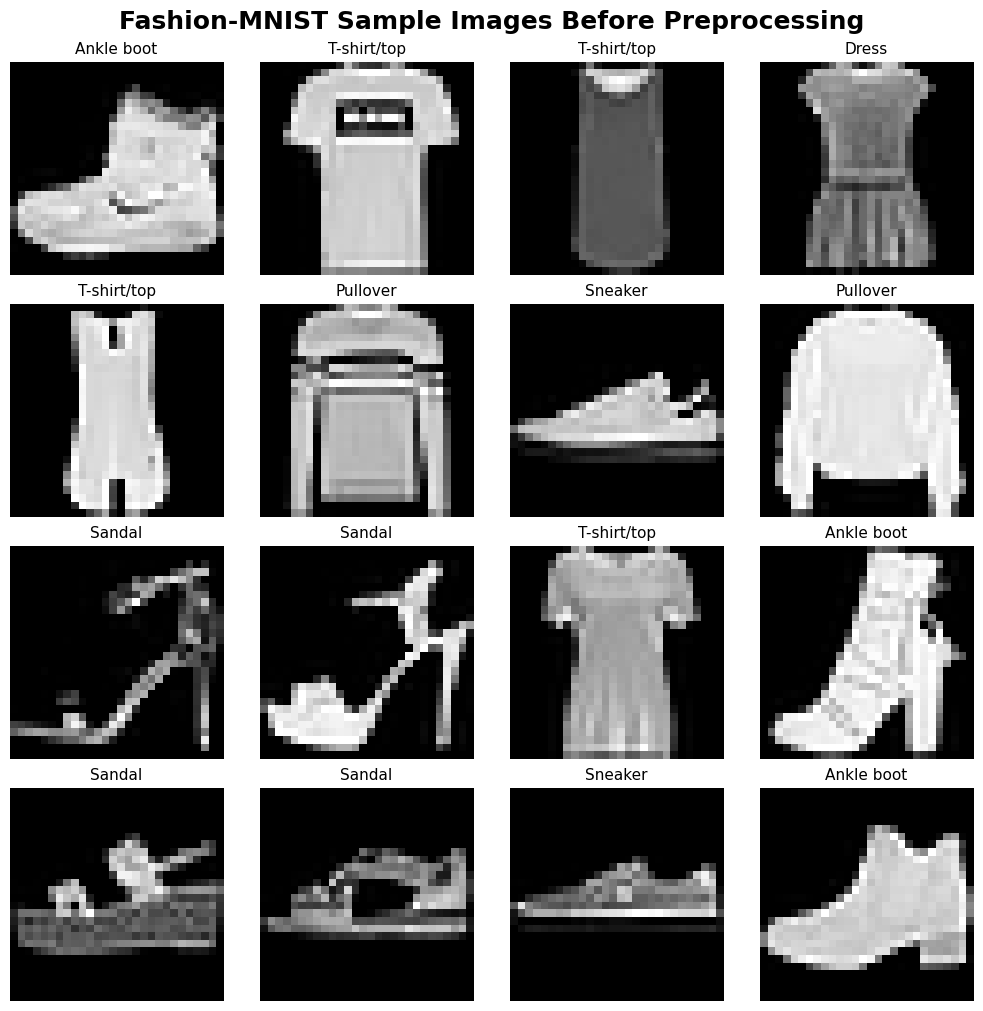

Single image shape: (28, 28)
Single image data type: uint8
Pixel range in first sample image: 0 to 255


In [3]:
# ============================================================
# Step 3: Visualize sample Fashion-MNIST images
# ============================================================

# Number of images to display
num_images = 16

# Select sample images and labels
sample_images = x_train[:num_images]
sample_labels = y_train[:num_images]

# Create a clean 4x4 image grid
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(10, 10),
    constrained_layout=True
)

fig.suptitle(
    "Fashion-MNIST Sample Images Before Preprocessing",
    fontsize=18,
    fontweight="bold"
)

# Plot each image with its class name
for ax, image, label in zip(axes.ravel(), sample_images, sample_labels):
    ax.imshow(image, cmap="gray")
    ax.set_title(class_names[label], fontsize=11)
    ax.axis("off")

plt.show()

# Print technical details for one image
print("Single image shape:", sample_images[0].shape)
print("Single image data type:", sample_images[0].dtype)
print("Pixel range in first sample image:", sample_images[0].min(), "to", sample_images[0].max())

## 3. Preprocess Images for Conv2D

For a convolutional autoencoder, we keep the image in 2D format instead of flattening it.

Each image is reshaped from:

`28 × 28`

to:

`28 × 28 × 1`

The extra `1` represents the grayscale channel.

Pixel values are also normalised from **0–255** to **0–1**.

In [ ]:
# ============================================================
# Step 4: Normalize images and add channel dimension
# ============================================================

# Normalize pixel values from 0-255 to 0-1
# This helps the neural network train more smoothly

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Add channel dimension for Conv2D
# Before: (60000, 28, 28)
# After:  (60000, 28, 28, 1)

x_train_conv = np.expand_dims(x_train_norm, axis=-1)
x_test_conv = np.expand_dims(x_test_norm, axis=-1)

# Print shape changes
print("Original training shape:", x_train.shape)
print("Normalized training shape:", x_train_norm.shape)
print("Conv2D training shape:", x_train_conv.shape)

print("\nOriginal test shape:", x_test.shape)
print("Normalized test shape:", x_test_norm.shape)
print("Conv2D test shape:", x_test_conv.shape)

# Confirm pixel range
print("\nPixel value range after normalization:")
print("Training min:", x_train_conv.min())
print("Training max:", x_train_conv.max())
print("Test min:", x_test_conv.min())
print("Test max:", x_test_conv.max())

Original training shape: (60000, 28, 28)
Normalized training shape: (60000, 28, 28)
Conv2D training shape: (60000, 28, 28, 1)

Original test shape: (10000, 28, 28)
Normalized test shape: (10000, 28, 28)
Conv2D test shape: (10000, 28, 28, 1)

Pixel value range after normalization:
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


### Preprocessing — Conclusion

The Fashion-MNIST images were successfully normalised from **0–255** to **0–1**.

Unlike the dense autoencoder, the images were **not flattened**.  
They were reshaped into **28 × 28 × 1**, so the convolutional autoencoder can learn spatial image patterns such as edges, curves, shapes, and textures.

## 4. Build the Convolutional Autoencoder

The convolutional autoencoder keeps the image structure as **28 × 28 × 1**.

The encoder compresses the image using:

`Conv2D(32) → MaxPooling → Conv2D(16) → MaxPooling`

The decoder reconstructs the image using:

`Conv2D(16) → UpSampling → Conv2D(32) → UpSampling → Conv2D(1)`

The final layer uses **sigmoid** so that reconstructed pixel values stay between **0 and 1**.

In [ ]:
# ============================================================
# Step 5: Build the convolutional autoencoder

# Architecture:
# Encoder: Conv2D(32) + MaxPooling → Conv2D(16) + MaxPooling
# Decoder: Conv2D(16) + UpSampling → Conv2D(32) + UpSampling → Conv2D(1)
# ============================================================

# Input image shape for Fashion-MNIST
# 28 = height, 28 = width, 1 = grayscale channel

input_shape = (28, 28, 1)

# -----------------------------
# Encoder
# -----------------------------

# Input layer receives one Fashion-MNIST image
input_image = keras.Input(shape=input_shape, name="input_image")

# First convolution layer:
# learns 32 local visual patterns such as edges, curves, and simple textures

x = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="encoder_conv_32"
)(input_image)

# First pooling layer:
# reduces image size from 28x28 to 14x14

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    padding="same",
    name="encoder_pool_1"
)(x)

# Second convolution layer:
# learns 16 deeper compressed image patterns

x = layers.Conv2D(
    filters=16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="encoder_conv_16"
)(x)

# Second pooling layer:
# reduces image size from 14x14 to 7x7

bottleneck = layers.MaxPooling2D(
    pool_size=(2, 2),
    padding="same",
    name="bottleneck_7x7x16"
)(x)

# -----------------------------
# Decoder
# -----------------------------

# Decoder starts rebuilding from the compressed 7x7x16 bottleneck
x = layers.Conv2D(
    filters=16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="decoder_conv_16"
)(bottleneck)

# First upsampling:
# expands image features from 7x7 to 14x14

x = layers.UpSampling2D(
    size=(2, 2),
    name="decoder_upsample_1"
)(x)

# Second decoder convolution:
# rebuilds richer image details using 32 filters

x = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="decoder_conv_32"
)(x)

# Second upsampling:
# expands image features from 14x14 back to 28x28

x = layers.UpSampling2D(
    size=(2, 2),
    name="decoder_upsample_2"
)(x)

# Final reconstruction layer:
# outputs one grayscale reconstructed image

reconstructed_image = layers.Conv2D(
    filters=1,
    kernel_size=(3, 3),
    activation="sigmoid",
    padding="same",
    name="reconstructed_output"
)(x)

# Full convolutional autoencoder model

conv_autoencoder = keras.Model(
    inputs=input_image,
    outputs=reconstructed_image,
    name="conv_autoencoder_fashion_mnist"
)

# Separate encoder model for later feature extraction

conv_encoder = keras.Model(
    inputs=input_image,
    outputs=bottleneck,
    name="conv_encoder_model"
)

# Print model structure

conv_autoencoder.summary()

Model: "conv_autoencoder_fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_32 (Conv2D)        │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_16 (Conv2D)        │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_7x7x16               │ (None, 7, 7, 16)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_16 (Conv2D)        │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_1              │ (None, 14, 14, 16)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_32 (Conv2D)        │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_2              │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Conv2D)   │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# Step 6: Compile the convolutional autoencoder
# ============================================================

# Compile the model
# Adam updates the model weights
# Binary crossentropy measures reconstruction error for 0-1 pixel values
conv_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("Convolutional autoencoder compiled successfully.")
print("Optimizer: Adam")
print("Loss function: Binary Crossentropy")

Convolutional autoencoder compiled successfully.
Optimizer: Adam
Loss function: Binary Crossentropy


## 6. Train the Convolutional Autoencoder

The convolutional autoencoder is trained to reconstruct Fashion-MNIST images.

Because this is still an autoencoder, the input and target are the same:

`x_train_conv → x_train_conv`

The model receives a clothing image and learns to rebuild that same clothing image.

We train for **20 epochs**, as required in the intermediate exercise.

In [8]:
# ============================================================
# Step 7: Train the convolutional autoencoder
# ============================================================

conv_history = conv_autoencoder.fit(
    x_train_conv,                 # Input images
    x_train_conv,                 # Target images are the same for reconstruction
    epochs=20,                    # Required by the intermediate exercise
    batch_size=256,               # Number of images processed per weight update
    shuffle=True,                 # Shuffle training images each epoch
    validation_data=(
        x_test_conv,              # Validation input images
        x_test_conv               # Validation target images
    ),
    verbose=1                     # Show training progress
)

print("Convolutional autoencoder training completed.")

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 210ms/step - loss: 0.2579 - val_loss: 0.2599
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 209ms/step - loss: 0.2576 - val_loss: 0.2597
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 206ms/step - loss: 0.2574 - val_loss: 0.2594
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 203ms/step - loss: 0.2572 - val_loss: 0.2592
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 52s 219ms/step - loss: 0.2570 - val_loss: 0.2590
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 57s 241ms/step - loss: 0.2568 - val_loss: 0.2588
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 207ms/step - loss: 0.2566 - val_loss: 0.2586
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 53s 224ms/step - loss: 0.2565 - val_loss: 0.2587
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 198ms/step - loss: 0.2563 - val_loss: 0.2583
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 205ms/step - loss: 0.2562 - val_loss: 0.2583
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 51s 218ms/step - loss: 0.2561 - val_loss: 0.2580
Epoch 12/20
235/235

## 7. Visualise Conv Autoencoder Training Performance

The loss curve helps us understand whether the convolutional autoencoder improved during training.

- **Training loss** measures reconstruction error on training images.
- **Validation loss** measures reconstruction error on unseen validation images.

A healthy training pattern is when both losses decrease and stay reasonably close.

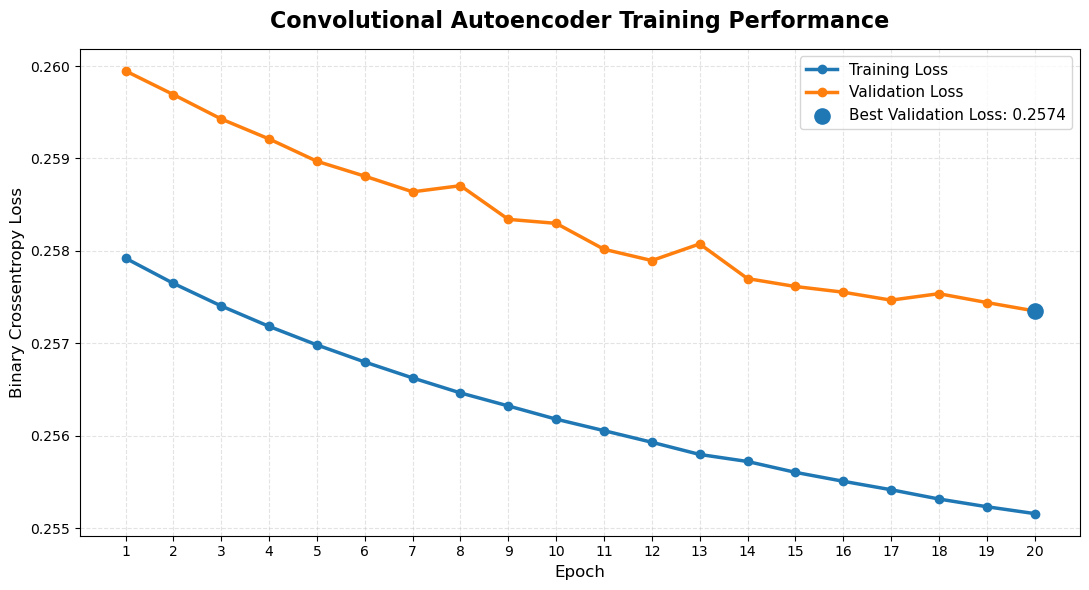

Final training loss: 0.2552
Final validation loss: 0.2574
Best validation loss: 0.2574 at epoch 20


In [9]:
# ============================================================
# Step 8: Plot convolutional autoencoder training performance
# ============================================================

# Convert training history into a DataFrame
conv_history_df = pd.DataFrame(conv_history.history)

# Add epoch numbers starting from 1
conv_history_df["epoch"] = range(1, len(conv_history_df) + 1)

# Identify best validation loss
best_epoch = conv_history_df["val_loss"].idxmin() + 1
best_val_loss = conv_history_df["val_loss"].min()

# Create a polished loss curve
plt.figure(figsize=(11, 6))

plt.plot(
    conv_history_df["epoch"],
    conv_history_df["loss"],
    marker="o",
    linewidth=2.5,
    label="Training Loss"
)

plt.plot(
    conv_history_df["epoch"],
    conv_history_df["val_loss"],
    marker="o",
    linewidth=2.5,
    label="Validation Loss"
)

# Highlight the best validation loss
plt.scatter(
    best_epoch,
    best_val_loss,
    s=120,
    zorder=5,
    label=f"Best Validation Loss: {best_val_loss:.4f}"
)

plt.title(
    "Convolutional Autoencoder Training Performance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary Crossentropy Loss", fontsize=12)

plt.xticks(conv_history_df["epoch"])
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

# Print final results
print("Final training loss:", round(conv_history_df["loss"].iloc[-1], 4))
print("Final validation loss:", round(conv_history_df["val_loss"].iloc[-1], 4))
print("Best validation loss:", round(best_val_loss, 4), "at epoch", best_epoch)

### Conv Autoencoder Training — Conclusion

The convolutional autoencoder trained successfully.

Both training and validation loss decreased across epochs, showing that the model learned to reconstruct Fashion-MNIST images better over time.

The validation loss stayed slightly higher than the training loss, which is expected because validation images are unseen during training.

## 8. Generate Reconstructed Fashion-MNIST Images

After training, we use the convolutional autoencoder to reconstruct unseen Fashion-MNIST test images.

To keep the notebook efficient on CPU, we generate reconstructions for a smaller test subset first.

We will compare:
- original images
- reconstructed images
- reconstruction error values

In [ ]:
# ============================================================
# Step 9: Generate reconstructed Fashion-MNIST images
# ============================================================

# Use a smaller test subset for faster prediction on CPU
x_test_subset = x_test_conv[:2000]
y_test_subset = y_test[:2000]

# Generate reconstructed images
conv_reconstructed_subset = conv_autoencoder.predict(
    x_test_subset,
    batch_size=128,
    verbose=1
)

# Calculate Mean Squared Error per image
# This compares each original image with its reconstructed version

conv_reconstruction_errors = np.mean(
    np.square(x_test_subset - conv_reconstructed_subset),
    axis=(1, 2, 3)
)

# Print reconstruction summary
print("Original subset shape:", x_test_subset.shape)
print("Reconstructed subset shape:", conv_reconstructed_subset.shape)

print("\nAverage reconstruction error:", round(conv_reconstruction_errors.mean(), 6))
print("Minimum reconstruction error:", round(conv_reconstruction_errors.min(), 6))
print("Maximum reconstruction error:", round(conv_reconstruction_errors.max(), 6))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Original subset shape: (2000, 28, 28, 1)
Reconstructed subset shape: (2000, 28, 28, 1)

Average reconstruction error: 0.004471
Minimum reconstruction error: 0.000831
Maximum reconstruction error: 0.053097


## 9. Visualise Original vs Reconstructed Fashion-MNIST Images

This comparison helps us understand reconstruction quality visually.

The top row shows the original images.  
The bottom row shows the reconstructed images created by the convolutional autoencoder.

The MSE value shows how different each reconstructed image is from its original version.

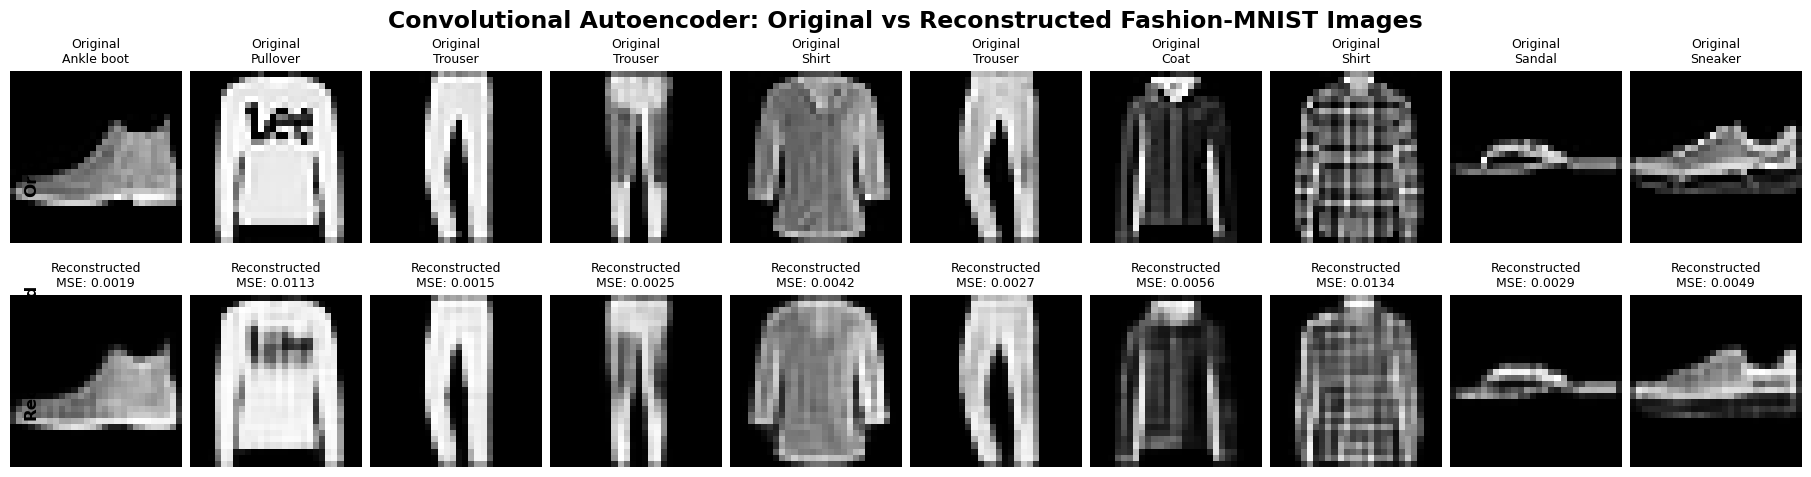

In [11]:
# ============================================================
# Step 10: Visualize original vs reconstructed Fashion-MNIST images
# ============================================================

# Number of images to display
num_images = 10

# Select sample images
original_samples = x_test_subset[:num_images]
reconstructed_samples = conv_reconstructed_subset[:num_images]
sample_errors = conv_reconstruction_errors[:num_images]
sample_labels = y_test_subset[:num_images]

# Remove the channel dimension for plotting
original_samples_plot = original_samples.squeeze()
reconstructed_samples_plot = reconstructed_samples.squeeze()

# Create a 2-row comparison grid
fig, axes = plt.subplots(
    nrows=2,
    ncols=num_images,
    figsize=(18, 4.8),
    constrained_layout=True
)

fig.suptitle(
    "Convolutional Autoencoder: Original vs Reconstructed Fashion-MNIST Images",
    fontsize=17,
    fontweight="bold"
)

# Row 1: Original images
for i in range(num_images):
    axes[0, i].imshow(original_samples_plot[i], cmap="gray")
    axes[0, i].set_title(f"Original\n{class_names[sample_labels[i]]}", fontsize=9)
    axes[0, i].axis("off")

# Row 2: Reconstructed images
for i in range(num_images):
    axes[1, i].imshow(reconstructed_samples_plot[i], cmap="gray")
    axes[1, i].set_title(f"Reconstructed\nMSE: {sample_errors[i]:.4f}", fontsize=9)
    axes[1, i].axis("off")

# Add row labels
fig.text(
    0.01, 0.68, "Original",
    fontsize=12,
    fontweight="bold",
    rotation=90,
    va="center"
)

fig.text(
    0.01, 0.28, "Reconstructed",
    fontsize=12,
    fontweight="bold",
    rotation=90,
    va="center"
)

plt.show()

### Reconstruction Visualisation — Conclusion

The convolutional autoencoder reconstructed the main structure of Fashion-MNIST images successfully.

The model preserved large visual patterns such as clothing outline, trouser shape, shoe profile, and coat structure.

Some fine details were lost, especially:
- fabric texture
- sharp edges
- thin straps
- small shoe details
- complex shirt patterns

This is expected because the model compresses each image before reconstruction.

## 10. Build a Dense Autoencoder Baseline for Comparison

To compare reconstruction quality, we build a simple dense autoencoder on Fashion-MNIST.

The dense model flattens each image from **28 × 28 × 1** into **784 values**, while the convolutional model keeps the 2D image structure.

Both models will be compared using Mean Squared Error on the same 100 test images.

In [13]:
# ============================================================
# Step 11: Prepare flattened Fashion-MNIST data for dense baseline
# ============================================================

# Flatten Conv2D data from 28x28x1 into 784 values
x_train_flat_fashion = x_train_conv.reshape((x_train_conv.shape[0], 28 * 28))
x_test_flat_fashion = x_test_conv.reshape((x_test_conv.shape[0], 28 * 28))

print("Flattened Fashion-MNIST training shape:", x_train_flat_fashion.shape)
print("Flattened Fashion-MNIST test shape:", x_test_flat_fashion.shape)

Flattened Fashion-MNIST training shape: (60000, 784)
Flattened Fashion-MNIST test shape: (10000, 784)


## 11. Build a Dense Autoencoder Baseline

To compare the convolutional autoencoder fairly, we create a dense autoencoder baseline on the same Fashion-MNIST dataset.

The dense model uses flattened images:

`28 × 28 × 1 → 784 values`

Architecture:

`784 → 128 → 32 → 128 → 784`

This model does not preserve the 2D image structure, so we expect the convolutional autoencoder to perform better on image reconstruction.

In [14]:
# ============================================================
# Step 12: Build and compile dense autoencoder baseline
# ============================================================

# Define layer sizes
input_dim = 784
hidden_dim = 128
bottleneck_dim = 32

# Input layer for flattened Fashion-MNIST image
dense_input = keras.Input(shape=(input_dim,), name="dense_fashion_input")

# Encoder: compress 784 values to 128, then to 32
x = layers.Dense(
    hidden_dim,
    activation="relu",
    name="dense_encoder_128"
)(dense_input)

dense_bottleneck = layers.Dense(
    bottleneck_dim,
    activation="relu",
    name="dense_bottleneck_32"
)(x)

# Decoder: expand 32 back to 128, then to 784
x = layers.Dense(
    hidden_dim,
    activation="relu",
    name="dense_decoder_128"
)(dense_bottleneck)

dense_output = layers.Dense(
    input_dim,
    activation="sigmoid",
    name="dense_reconstructed_output"
)(x)

# Create dense autoencoder model
dense_fashion_autoencoder = keras.Model(
    inputs=dense_input,
    outputs=dense_output,
    name="dense_autoencoder_fashion_mnist"
)

# Compile model
dense_fashion_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Show model structure
dense_fashion_autoencoder.summary()

Model: "dense_autoencoder_fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_fashion_input             │ (None, 784)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_encoder_128 (Dense)       │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_bottleneck_32 (Dense)     │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_decoder_128 (Dense)       │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_reconstructed_output      │ (None, 784)            │       101,136 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Train the Dense Autoencoder Baseline

The dense baseline is trained on flattened Fashion-MNIST images.

This model is used only for comparison with the convolutional autoencoder.

To keep the notebook efficient on CPU, we train it on a smaller subset and fewer epochs.

In [15]:
# ============================================================
# Step 13: Train dense autoencoder baseline on Fashion-MNIST
# ============================================================

# CPU-friendly subset
x_train_dense_fast = x_train_flat_fashion[:10000]
x_val_dense_fast = x_test_flat_fashion[:2000]

print("Dense baseline training shape:", x_train_dense_fast.shape)
print("Dense baseline validation shape:", x_val_dense_fast.shape)

# Train dense baseline
dense_history = dense_fashion_autoencoder.fit(
    x_train_dense_fast,           # Input images as flattened 784 values
    x_train_dense_fast,           # Target is the same image
    epochs=3,                     # Light training for CPU
    batch_size=128,               # Smaller batch size for older Mac
    shuffle=True,
    validation_data=(
        x_val_dense_fast,
        x_val_dense_fast
    ),
    verbose=1
)

print("Dense Fashion-MNIST baseline training completed.")

Dense baseline training shape: (10000, 784)
Dense baseline validation shape: (2000, 784)
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4581 - val_loss: 0.3679
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3434 - val_loss: 0.3305
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3186 - val_loss: 0.3158
Dense Fashion-MNIST baseline training completed.


## 13. Compare Dense vs Convolutional Autoencoder Reconstruction Error

In this step, we compare both models on the same 100 Fashion-MNIST test images.

The comparison uses **Mean Squared Error (MSE)**:

- Lower MSE = better reconstruction
- Higher MSE = worse reconstruction

The dense autoencoder uses flattened images, while the convolutional autoencoder keeps the 2D image structure.

In [16]:
# ============================================================
# Step 14: Compare Dense vs Conv Autoencoder reconstruction error
# ============================================================

# Use the same 100 test images for both models
n_compare = 100

# Conv input format: 28x28x1
x_compare_conv = x_test_conv[:n_compare]

# Dense input format: flattened 784 values
x_compare_flat = x_test_flat_fashion[:n_compare]

# -----------------------------
# Dense autoencoder predictions
# -----------------------------
dense_reconstructed_flat = dense_fashion_autoencoder.predict(
    x_compare_flat,
    batch_size=64,
    verbose=0
)

# Reshape dense reconstructions back to 28x28x1 for fair comparison
dense_reconstructed_conv_shape = dense_reconstructed_flat.reshape((-1, 28, 28, 1))

# -----------------------------
# Conv autoencoder predictions
# -----------------------------
conv_reconstructed_compare = conv_autoencoder.predict(
    x_compare_conv,
    batch_size=64,
    verbose=0
)

# -----------------------------
# Calculate MSE per image
# -----------------------------

# Dense reconstruction error
dense_mse = np.mean(
    np.square(x_compare_conv - dense_reconstructed_conv_shape),
    axis=(1, 2, 3)
)

# Conv reconstruction error
conv_mse = np.mean(
    np.square(x_compare_conv - conv_reconstructed_compare),
    axis=(1, 2, 3)
)

# Create comparison summary
comparison_df = pd.DataFrame({
    "Model": ["Dense Autoencoder", "Convolutional Autoencoder"],
    "Average MSE": [dense_mse.mean(), conv_mse.mean()],
    "Minimum MSE": [dense_mse.min(), conv_mse.min()],
    "Maximum MSE": [dense_mse.max(), conv_mse.max()]
})

# Display rounded comparison table
comparison_df_rounded = comparison_df.copy()
comparison_df_rounded[["Average MSE", "Minimum MSE", "Maximum MSE"]] = (
    comparison_df_rounded[["Average MSE", "Minimum MSE", "Maximum MSE"]].round(6)
)

comparison_df_rounded

,Model,Average MSE,Minimum MSE,Maximum MSE
0,Dense Autoencoder,0.022474,0.008342,0.059023
1,Convolutional Autoencoder,0.003979,0.000969,0.019004


### Dense vs Convolutional Autoencoder — Interpretation

The convolutional autoencoder achieved a much lower reconstruction error than the dense autoencoder.

The dense autoencoder had an average MSE of **0.022474**, while the convolutional autoencoder achieved an average MSE of **0.003979**.

This shows that the convolutional model reconstructed Fashion-MNIST images more accurately.

The main reason is that the convolutional autoencoder keeps the image in its original **2D structure**, allowing it to learn local image patterns such as edges, curves, outlines, and textures.  
The dense autoencoder flattens the image into a 784-value row, which removes the natural spatial structure of the image.

### Reconstruction Error Difference

To compare the two models clearly, we calculate:

`MSE Difference = Dense Autoencoder MSE - Conv Autoencoder MSE`

A larger positive difference means the Conv Autoencoder made fewer reconstruction mistakes.

We also calculate percentage reduction:

`Reduction % = (MSE Difference / Dense Autoencoder MSE) × 100`

In [17]:
# ============================================================
# Step 15: Show MSE difference between Dense and Conv Autoencoder
# ============================================================

# Extract average MSE values
dense_avg_mse = comparison_df.loc[
    comparison_df["Model"] == "Dense Autoencoder", 
    "Average MSE"
].values[0]

conv_avg_mse = comparison_df.loc[
    comparison_df["Model"] == "Convolutional Autoencoder", 
    "Average MSE"
].values[0]

# Calculate difference and percentage reduction
mse_difference = dense_avg_mse - conv_avg_mse
mse_reduction_percent = (mse_difference / dense_avg_mse) * 100

# Create a clean summary table
mse_summary_df = pd.DataFrame({
    "Metric": [
        "Dense Autoencoder Average MSE",
        "Convolutional Autoencoder Average MSE",
        "MSE Difference",
        "Error Reduction (%)"
    ],
    "Value": [
        dense_avg_mse,
        conv_avg_mse,
        mse_difference,
        mse_reduction_percent
    ]
})

# Display rounded table
mse_summary_df["Value"] = mse_summary_df["Value"].round(6)
mse_summary_df

,Metric,Value
0,Dense Autoencoder Average MSE,0.022474
1,Convolutional Autoencoder Average MSE,0.003979
2,MSE Difference,0.018496
3,Error Reduction (%),82.297438


## 14. Extract Bottleneck Features from the Conv Encoder

The convolutional autoencoder contains an encoder and a decoder.

For feature extraction, we use only the encoder part.

The encoder converts each Fashion-MNIST image into compressed bottleneck features with shape:

`7 × 7 × 16`

These features represent the compressed visual information learned by the autoencoder.

In [18]:
# ============================================================
# Step 17: Extract bottleneck features using the trained encoder
# ============================================================

# Use a smaller subset for CPU-friendly feature extraction and t-SNE
n_features = 1000

x_feature_subset = x_test_conv[:n_features]
y_feature_subset = y_test[:n_features]

# Extract compressed features from the encoder
# Output shape will be: (1000, 7, 7, 16)
bottleneck_features = conv_encoder.predict(
    x_feature_subset,
    batch_size=128,
    verbose=1
)

# Flatten bottleneck feature maps for t-SNE
# 7 x 7 x 16 = 784 features per image
bottleneck_features_flat = bottleneck_features.reshape((n_features, -1))

print("Input image subset shape:", x_feature_subset.shape)
print("Bottleneck feature shape:", bottleneck_features.shape)
print("Flattened bottleneck feature shape:", bottleneck_features_flat.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Input image subset shape: (1000, 28, 28, 1)
Bottleneck feature shape: (1000, 7, 7, 16)
Flattened bottleneck feature shape: (1000, 784)


## 15. Visualise Bottleneck Features with t-SNE

The encoder creates compressed bottleneck features for each image.

However, these features are still high-dimensional, so we cannot view them directly.

We use **t-SNE** to reduce the bottleneck features into 2 dimensions for visualisation.

The class labels are used only for colouring the plot, not for training the autoencoder.

In [19]:
# ============================================================
# Step 18: Reduce bottleneck features using PCA + t-SNE
# ============================================================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Step 1: PCA reduces 784 features to 50 features
# This makes t-SNE faster on CPU
pca = PCA(n_components=50, random_state=42)

bottleneck_features_pca = pca.fit_transform(bottleneck_features_flat)

print("Original bottleneck feature shape:", bottleneck_features_flat.shape)
print("PCA-reduced feature shape:", bottleneck_features_pca.shape)
print("Explained variance retained by PCA:", round(pca.explained_variance_ratio_.sum(), 4))

# Step 2: t-SNE reduces 50 PCA features to 2D for visualisation
tsne = TSNE(
    n_components=2,          # 2D output for plotting
    perplexity=30,           # balances local and global structure
    learning_rate="auto",    # lets sklearn choose a suitable learning rate
    init="pca",              # stable starting point
    random_state=42
)

tsne_features = tsne.fit_transform(bottleneck_features_pca)

print("t-SNE output shape:", tsne_features.shape)

Original bottleneck feature shape: (1000, 784)
PCA-reduced feature shape: (1000, 50)
Explained variance retained by PCA: 0.9345
t-SNE output shape: (1000, 2)


## 16. Plot t-SNE Visualisation of Encoder Features

The t-SNE plot shows the compressed encoder features in 2D space.

Each point represents one Fashion-MNIST image.  
The colour represents the true fashion class label.

If the encoder learned useful visual features, similar item types should appear closer together.

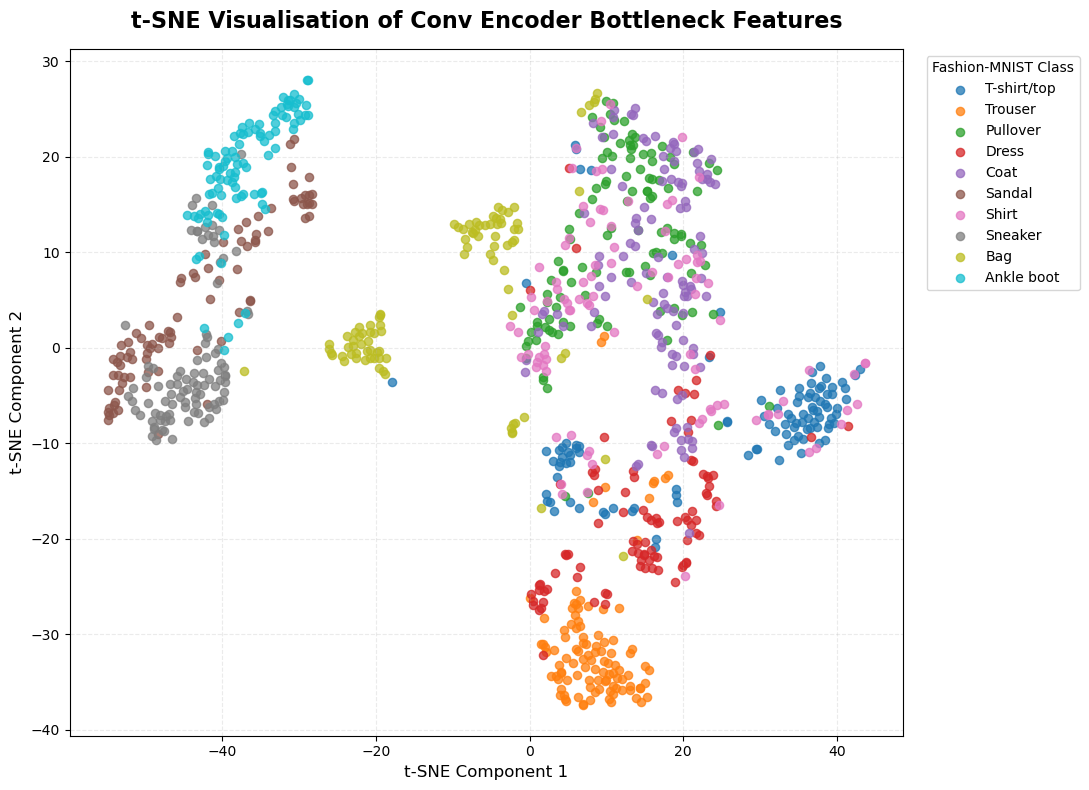

In [20]:
# ============================================================
# Step 19: Plot t-SNE visualization of bottleneck features
# ============================================================

# Create DataFrame for plotting
tsne_df = pd.DataFrame({
    "TSNE_1": tsne_features[:, 0],
    "TSNE_2": tsne_features[:, 1],
    "Label": y_feature_subset,
    "Class": [class_names[label] for label in y_feature_subset]
})

# Create figure
plt.figure(figsize=(11, 8))

# Plot each class separately for a clean legend
for class_id, class_name in enumerate(class_names):
    class_data = tsne_df[tsne_df["Label"] == class_id]
    
    plt.scatter(
        class_data["TSNE_1"],
        class_data["TSNE_2"],
        s=35,
        alpha=0.75,
        label=class_name
    )

plt.title(
    "t-SNE Visualisation of Conv Encoder Bottleneck Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.25)

plt.legend(
    title="Fashion-MNIST Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

### t-SNE Feature Visualisation — Interpretation

The t-SNE plot shows that the convolutional encoder learned useful compressed image features.

Some Fashion-MNIST classes form clear clusters, especially **Trouser**, **Bag**, and footwear classes such as **Sneaker**, **Sandal**, and **Ankle boot**.

However, visually similar clothing categories such as **T-shirt/top**, **Pullover**, **Coat**, **Shirt**, and **Dress** overlap more strongly.

This is expected because these clothing items share similar shapes, sleeves, textures, and body structure.

Overall, the encoder features are partially separable, which means the convolutional autoencoder learned meaningful visual representations even though it was trained only for reconstruction and not classification.

## 17. Optional Extension: UMAP Visualisation of Encoder Features

UMAP is another dimensionality reduction method used to visualise high-dimensional data in 2D.

Like t-SNE, it helps us inspect whether similar images are close together in the encoder feature space.

This is an optional extension beyond the core intermediate task, but it gives a stronger comparison of feature visualisation methods.

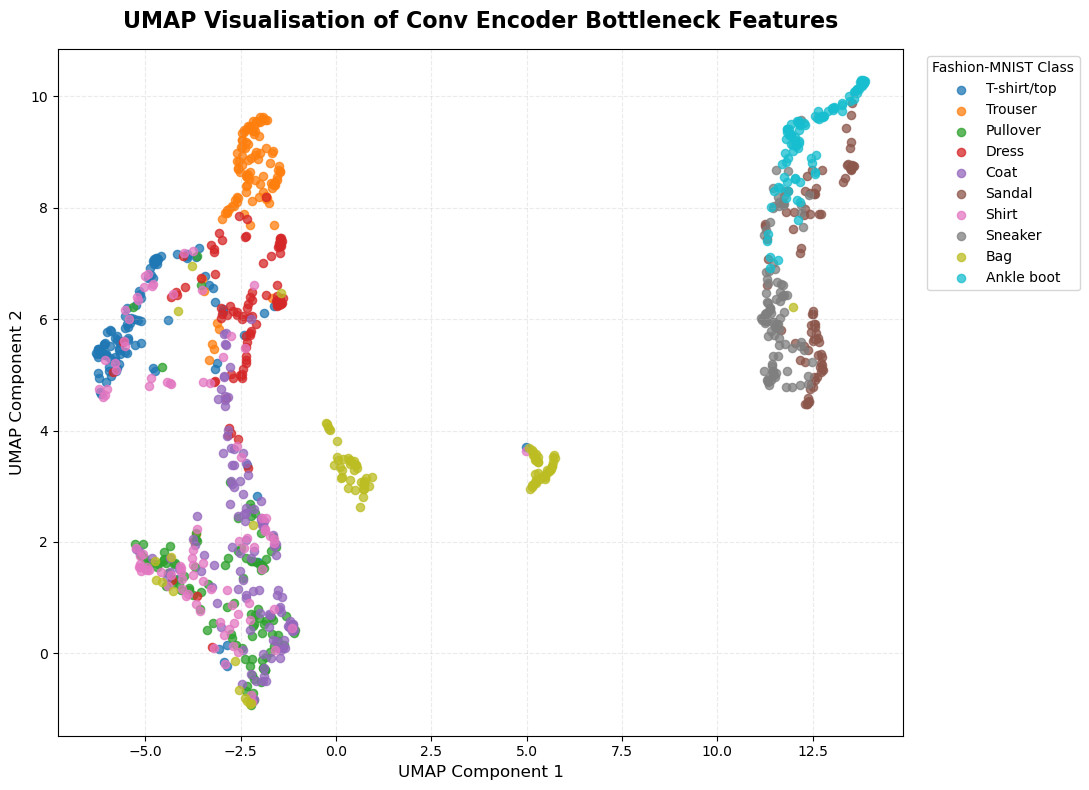

In [23]:
# ============================================================
# Step 22: Plot UMAP visualization of bottleneck features
# ============================================================

# Create DataFrame for plotting
umap_df = pd.DataFrame({
    "UMAP_1": umap_features[:, 0],
    "UMAP_2": umap_features[:, 1],
    "Label": y_feature_subset,
    "Class": [class_names[label] for label in y_feature_subset]
})

# Create figure
plt.figure(figsize=(11, 8))

# Plot each class separately for a clean legend
for class_id, class_name in enumerate(class_names):
    class_data = umap_df[umap_df["Label"] == class_id]
    
    plt.scatter(
        class_data["UMAP_1"],
        class_data["UMAP_2"],
        s=35,
        alpha=0.75,
        label=class_name
    )

plt.title(
    "UMAP Visualisation of Conv Encoder Bottleneck Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("UMAP Component 1", fontsize=12)
plt.ylabel("UMAP Component 2", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.25)

plt.legend(
    title="Fashion-MNIST Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

### UMAP Feature Visualisation — Interpretation

The UMAP plot provides an additional view of the convolutional encoder’s compressed feature space.

Several visually distinct classes form meaningful groups. Footwear classes such as **Sneaker**, **Sandal**, and **Ankle boot** appear close to each other, which makes sense because they share similar shapes and visual structures.

The **Bag** and **Trouser** classes also show visible grouping.

Upper-body clothing classes such as **T-shirt/top**, **Pullover**, **Coat**, **Shirt**, and **Dress** overlap more strongly because their visual appearance is more similar.

Overall, UMAP confirms that the convolutional encoder learned useful visual representations from the Fashion-MNIST images.

## Intermediate Convolutional Autoencoder — Final Conclusion

In this notebook, we built a convolutional autoencoder on Fashion-MNIST.

### What was done

- Loaded and inspected Fashion-MNIST images
- Normalised pixel values from **0–255** to **0–1**
- Reshaped images into **28 × 28 × 1** for Conv2D
- Built a convolutional autoencoder using Conv2D, MaxPooling, and UpSampling
- Trained the model to reconstruct Fashion-MNIST images
- Visualised original and reconstructed images
- Compared reconstruction error against a dense autoencoder baseline
- Extracted bottleneck features using the trained encoder
- Visualised encoder features using **PCA + t-SNE**
- Added an optional **UMAP** visualisation for stronger feature-space analysis

### Key result

The convolutional autoencoder reconstructed Fashion-MNIST images much better than the dense autoencoder.

The Dense Autoencoder achieved an average MSE of **0.022474**, 

while the Convolutional Autoencoder achieved an average MSE of **0.003979**.

This means the Convolutional Autoencoder reduced reconstruction error by approximately **82.3%**.

### Feature-space insight
The t-SNE and UMAP plots showed that the encoder learned meaningful compressed visual features.

Some classes, such as **Trouser**, **Bag**, and footwear categories, formed clearer groups. 

Similar clothing classes such as **T-shirt/top**, **Pullover**, **Coat**, **Shirt**, and **Dress** overlapped more because they share similar shapes.

### Final takeaway
Convolutional autoencoders are better suited for image reconstruction because they preserve spatial image structure and learn local visual patterns such as edges, curves, textures, and object outlines.